### 데이터 기본 정보

Seoul Bike Sharing Demand는 서울의 시간별 자전거 대여량과 기상 정보가 담긴 데이터입니다.
로컬 파일에는 2017년 12월부터 2018년 11월까지 8,760개 관측치, 정답을 포함해 14개 컬럼이 있습니다.

출처: [UCI Seoul Bike Sharing Demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand),
[DOI: 10.24432/C5F62R](https://doi.org/10.24432/C5F62R). 라이선스: CC BY 4.0.

| 컬럼 | 뜻 |
|---|---|
| `Date`, `Hour` | 날짜와 시간. 로컬 CSV의 날짜는 **일/월/년** 순서입니다. |
| `Rented Bike Count` | **정답:** 해당 시간의 대여량(대) |
| `Temperature(°C)`, `Humidity(%)` | 기온과 습도 |
| `Wind speed (m/s)`, `Visibility (10m)` | 풍속과 가시거리 |
| `Dew point temperature(°C)` | 이슬점 온도 |
| `Solar Radiation (MJ/m2)` | 일사량 |
| `Rainfall(mm)`, `Snowfall (cm)` | 강수량과 적설량 |
| `Seasons`, `Holiday` | 계절과 공휴일 여부 |
| `Functioning Day` | 해당 시간의 대여 시스템 운영 여부 |

여기선 어떤 평가 지표를 활용하면 좋을까요?

정답은 없지만 여기선 MAE를 주로 활용하려고 합니다.

절댓값 차이가 실제 대여량 대수의 차이를 잘 나타낼 수 있기 때문입니다.

In [7]:
import pandas as pd

df = pd.read_csv("SeoulBikeData.csv", encoding="cp949")
df.head()

,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   object 
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(캜)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(캜)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   object 
 12  Holiday                   8760 non-null   object 
 13  Functioning Day           8760 non-null   object 
dtypes: float

앞서 봤듯, 문자열은 모델이 학습할 수 없습니다. 모델이 학습 가능한 숫자로 변형하거나 제거해야 합니다.

이번엔 문자열들을 어떻게 처리할건가요?

우선 Seasons, Holiday, Functioning Day는 순서나 크기 의미가 없는 범주형 값입니다.

만약 이를 고려하지 않고 Spring=1, Summer=2, 이런 식으로 값을 변형하게 되면 Summer(2)가 Spring(1)보다 더 중요한 값인가? 하고 모델이 잘못 학습해 버릴 수도 있습니다.

따라서 이런 순서, 크기 의미가 없는 경우엔 원-핫 인코딩을 통해 처리를 하는 것이 좋습니다.

* Spring = [1, 0, 0, 0]
* Summer = [0, 1, 0, 0]
* Autumn = [0, 0, 1, 0]
* Winter = [0, 0, 0, 1]

이런 식으로 표현하는거죠.

Date 컬럼의 경우 날짜가 거의 1년치에 달하고 이걸 전부 원핫 인코딩 하면 365개의 컬럼을 더 만들게 되기 때문에 불필요한 정보 증가가 될 수 있습니다. 따라서 여기선 drop 하도록 하겠습니다.

In [8]:
categorical_cols = ["Seasons", "Holiday", "Functioning Day"]

df_model = df.drop(columns=["Date"])
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
df_model.head()

,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,False,False,True,True,True
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,False,False,True,True,True
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,False,False,True,True,True
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,False,False,True,True,True
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,False,False,True,True,True


### Train / Test 분할

시계열 데이터이므로 랜덤 분할 대신 **시간 기준**으로 나눕니다.
데이터는 이미 날짜순(2017-12-01 ~ 2018-11-30)으로 정렬되어 있으므로,
뒤쪽 약 2개월(2018-10-01 이후)을 테스트로 떼어 "미래를 예측한다"는 상황에 가깝게 평가합니다.

In [9]:
date_parsed = pd.to_datetime(df["Date"], dayfirst=True)
split_date = pd.Timestamp("2018-10-01")

train_mask = date_parsed < split_date
test_mask = ~train_mask

X_train = df_model.drop(columns=["Rented Bike Count"])[train_mask]
y_train = df_model["Rented Bike Count"][train_mask]
X_test = df_model.drop(columns=["Rented Bike Count"])[test_mask]
y_test = df_model["Rented Bike Count"][test_mask]

print("train:", X_train.shape, " test:", X_test.shape)

train: (7296, 14)  test: (1464, 14)


### Baseline 모델 학습 & 평가

Linear Regression으로 학습하고, MAE(주 지표)와 RMSE(보조 지표)로 평가합니다.
MAE는 "평균적으로 몇 대 정도 틀리는가"를 그대로 보여주고, RMSE는 큰 오차에 더 민감해서 둘을 같이 보면
"오차가 고르게 퍼져있는지, 특정 구간에서 크게 틀리는지"에 대한 힌트를 얻을 수 있습니다.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  298.46
RMSE: 413.10


이렇게 값의 차이가 크다는 것은 모델이 특정 구간에서 유난히 많이 틀리는 케이스가 있다는 것입니다. (제곱을 거치기 때문에 큰 오차 하나가 평균을 확 끌어올리기 때문)

그러면 어디서 많이 틀리고 있는지 확인을 해봐야겠죠?

한 번 잔차 계산을 해서 통계 정보를 확인해 보도록 하겠습니다.

In [ ]:
error_df = X_test.copy()
error_df["actual"] = y_test
error_df["predicted"] = y_pred
# residual = 실제값과 예측값의 차이
error_df["residual"] = error_df["predicted"] - error_df["actual"]
# abs_error = 실제값과 예측값의 차이의 절댓값
error_df["abs_error"] = error_df["residual"].abs()

error_df[["actual", "predicted", "residual", "abs_error"]].describe()

,actual,predicted,residual,abs_error
count,1464.000000,1464.000000,1464.000000,1464.000000
mean,762.561475,719.212338,-43.349137,298.460965
std,591.324136,444.861647,410.955093,285.700343
min,0.000000,-1748.282976,-1748.282976,0.054499
25%,224.500000,430.294993,-235.464609,95.705665
50%,720.500000,753.286117,29.944907,227.001437
75%,1118.250000,1097.796662,222.664048,405.236647
max,2857.000000,1484.205953,1044.352206,1748.282976


시간대(`Hour`)별로 평균 오차를 비교해봅니다. 출퇴근 피크 시간대에서 유난히 크게 틀린다면,
"모델이 피크 수요 패턴을 제대로 학습하지 못했다"는 가설을 세워볼 수 있습니다.

In [13]:
hourly_error = error_df.groupby("Hour")[["actual", "predicted", "abs_error", "residual"]].mean()
hourly_error.columns = ["avg_actual", "avg_predicted", "avg_abs_error", "avg_residual"]
hourly_error.sort_values("avg_abs_error", ascending=False)

,avg_actual,avg_predicted,avg_abs_error,avg_residual
Hour,,,,
8,1222.770492,448.941132,851.442331,-773.829360
18,1645.114754,1051.547369,724.143421,-593.567386
7,690.590164,392.263218,415.471625,-298.326946
23,647.426230,1025.398287,378.796247,377.972058
17,1292.868852,1081.393725,354.328037,-211.475128
19,1204.163934,1044.562027,348.429218,-159.601907
5,133.131148,355.616601,335.184421,222.485453
4,135.163934,349.978130,328.521156,214.814196
9,750.377049,542.845438,280.321404,-207.531611


다른 시간대 들에 비해서 8시와 18시 구간에 값이 크게 흔들리는 것을 볼 수 있습니다.

avg_residual이 음수인 것을 보면 모델이 이 부분에서 '과소예측'을 하고 있단걸 볼 수 있습니다.

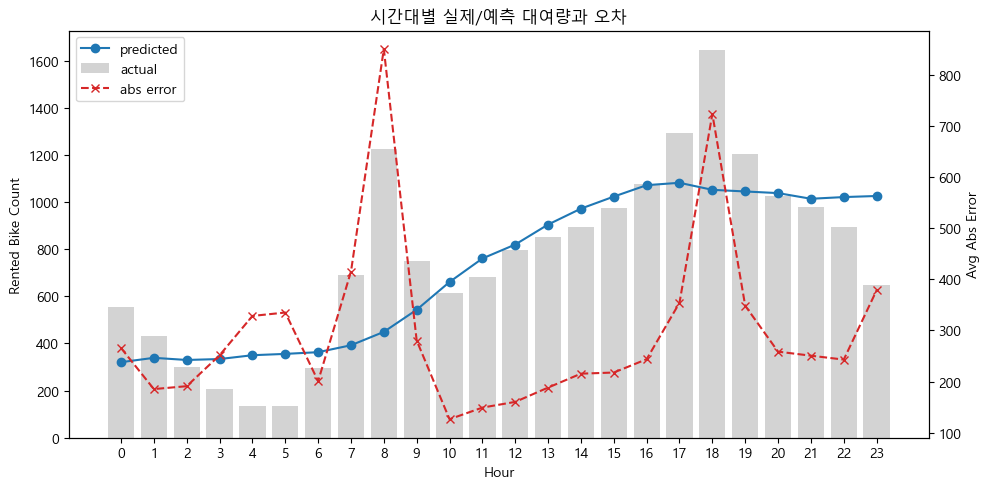

In [17]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(hourly_error.index, hourly_error["avg_actual"], color="lightgray", label="actual")
ax1.plot(hourly_error.index, hourly_error["avg_predicted"], color="tab:blue", marker="o", label="predicted")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Rented Bike Count")
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
ax2.plot(hourly_error.index, hourly_error["avg_abs_error"], color="tab:red", marker="x", linestyle="--", label="abs error")
ax2.set_ylabel("Avg Abs Error")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("시간대별 실제/예측 대여량과 오차")
plt.tight_layout()
plt.show()

보면 모델이 순간적으로 대여량이 급증하는 구간에 대해 예측을 제대로 하지 못한다는 것을 볼 수 있습니다.

predicted 곡선 자체도 상당히 완만하죠?

여기서 가설을 하나 세워볼 수 있습니다. "Hour를 연속형 숫자로 넣었기 때문에, 모델이 하루 중 두번의 수요 피크를 표현하지 못하고 완만한 선형 추세로만 예측하고 있다."

* Hour가 0~23 숫자 그대로 들어가고 있어 선형회귀에 Hour가 커질수록 대여량이 일정 비율로 변한다고 반영되고 있다.

### 개선 실험: Hour 원-핫 인코딩

가설을 검증하기 위해 `Hour`를 연속형 숫자 대신 원-핫 인코딩으로 바꿔서 같은 방식으로 다시 학습하고,
베이스라인과 지표를 비교합니다. 다른 조건(분할, 다른 피처)은 그대로 유지해서 이 변경 하나의 효과만 확인합니다.

In [18]:
df_model_v2 = df.drop(columns=["Date"])
df_model_v2 = pd.get_dummies(
    df_model_v2, columns=categorical_cols + ["Hour"], drop_first=True
)

X_train_v2 = df_model_v2.drop(columns=["Rented Bike Count"])[train_mask]
X_test_v2 = df_model_v2.drop(columns=["Rented Bike Count"])[test_mask]

model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train)
y_pred_v2 = model_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(y_test, y_pred_v2)
rmse_v2 = root_mean_squared_error(y_test, y_pred_v2)

print(f"[Baseline]   MAE: {mae:.2f}   RMSE: {rmse:.2f}")
print(f"[Hour 원핫]   MAE: {mae_v2:.2f}   RMSE: {rmse_v2:.2f}")

[Baseline]   MAE: 298.46   RMSE: 413.10
[Hour 원핫]   MAE: 243.73   RMSE: 337.04


지표가 많이 내려간 걸 확인할 수 있습니다.

In [ ]:
error_df_v2 = X_test.copy()
error_df_v2["actual"] = y_test
error_df_v2["abs_error_v2"] = (y_pred_v2 - y_test).abs()

hourly_compare = error_df_v2.groupby("Hour")["abs_error_v2"].mean().to_frame()
hourly_compare["abs_error_baseline"] = hourly_error["avg_abs_error"]
hourly_compare.loc[[8, 18]]

,abs_error_v2,abs_error_baseline
Hour,,
8,656.734208,851.442331
18,553.996222,724.143421


실제로 피크 시간에서 오차도 크게 줄어든 것을 볼 수 있습니다. (v2가 바꿔서 학습한 결과)

### Error Analysis (2차): 요일 효과

8시·18시는 "출퇴근 피크"인데, 이 패턴은 보통 **평일에만** 뚜렷하고 주말엔 다르게 나타나요.
지금 데이터엔 요일 정보가 없어서 모델이 평일/주말을 구분하지 못하고 있을 수 있습니다.
`Date`에서 요일을 뽑아 평일/주말로 나눠, 시간대별 실제 대여량 패턴이 정말 다른지 먼저 그래프로 확인합니다.

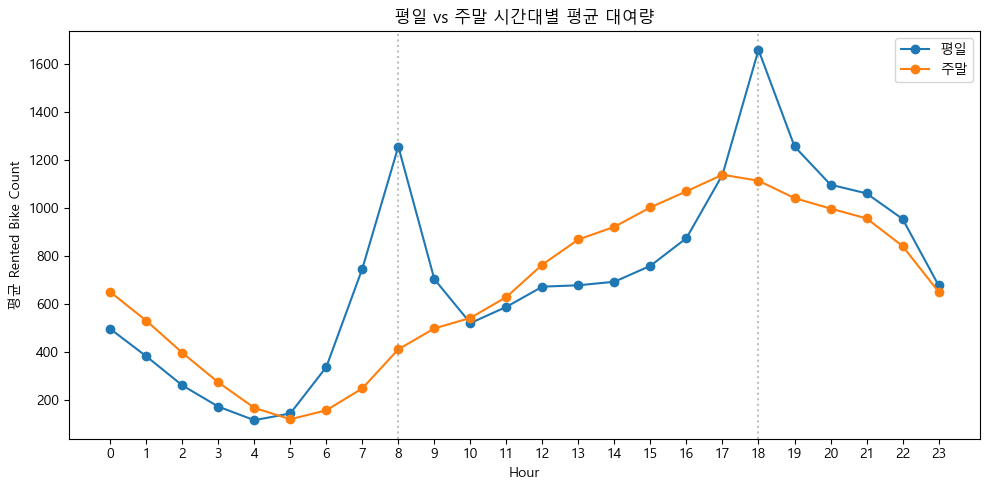

In [20]:
is_weekend = date_parsed.dt.dayofweek.isin([5, 6])

weekday_pattern = df[~is_weekend].groupby("Hour")["Rented Bike Count"].mean()
weekend_pattern = df[is_weekend].groupby("Hour")["Rented Bike Count"].mean()

plt.figure(figsize=(10, 5))
plt.plot(weekday_pattern.index, weekday_pattern.values, marker="o", label="평일")
plt.plot(weekend_pattern.index, weekend_pattern.values, marker="o", label="주말")
plt.axvline(8, color="gray", linestyle=":", alpha=0.5)
plt.axvline(18, color="gray", linestyle=":", alpha=0.5)
plt.xlabel("Hour")
plt.ylabel("평균 Rented Bike Count")
plt.xticks(range(0, 24))
plt.title("평일 vs 주말 시간대별 평균 대여량")
plt.legend()
plt.tight_layout()
plt.show()

패턴이 다르다면, v2 모델(Hour 원-핫)의 8시·18시 오차도 평일/주말로 나눠서 실제로 평일 쪽에서 더 크게 틀리는지 확인합니다.

In [21]:
error_df_v2["is_weekend"] = is_weekend[test_mask].values

peak_error = (
    error_df_v2[error_df_v2["Hour"].isin([8, 18])]
    .groupby(["Hour", "is_weekend"])["abs_error_v2"]
    .mean()
    .unstack()
)
peak_error.columns = ["평일", "주말"]
peak_error

,평일,주말
Hour,,
8,708.480692,511.197222
18,597.052421,432.900663


### 개선 실험: is_weekend 피처 추가

v2(Hour 원-핫)에 `is_weekend` 피처를 추가해서 v3로 다시 학습합니다. 다른 조건은 그대로 유지해서
이 변경 하나의 효과만 확인합니다.

In [22]:
df_model_v3 = df_model_v2.copy()
df_model_v3["is_weekend"] = is_weekend.astype(int).values

X_train_v3 = df_model_v3.drop(columns=["Rented Bike Count"])[train_mask]
X_test_v3 = df_model_v3.drop(columns=["Rented Bike Count"])[test_mask]

model_v3 = LinearRegression()
model_v3.fit(X_train_v3, y_train)
y_pred_v3 = model_v3.predict(X_test_v3)

mae_v3 = mean_absolute_error(y_test, y_pred_v3)
rmse_v3 = root_mean_squared_error(y_test, y_pred_v3)

print(f"[Hour 원핫]        MAE: {mae_v2:.2f}   RMSE: {rmse_v2:.2f}")
print(f"[+ is_weekend]     MAE: {mae_v3:.2f}   RMSE: {rmse_v3:.2f}")

[Hour 원핫]        MAE: 243.73   RMSE: 337.04
[+ is_weekend]     MAE: 242.43   RMSE: 334.16


In [23]:
error_df_v3 = X_test.copy()
error_df_v3["actual"] = y_test
error_df_v3["abs_error_v3"] = (y_pred_v3 - y_test).abs()
error_df_v3["is_weekend"] = is_weekend[test_mask].values

peak_error_v3 = (
    error_df_v3[error_df_v3["Hour"].isin([8, 18])]
    .groupby(["Hour", "is_weekend"])["abs_error_v3"]
    .mean()
    .unstack()
)
peak_error_v3.columns = ["평일", "주말"]

print("[Hour 원핫] 평일/주말 8·18시 오차")
print(peak_error)
print()
print("[+ is_weekend] 평일/주말 8·18시 오차")
print(peak_error_v3)

[Hour 원핫] 평일/주말 8·18시 오차
              평일          주말
Hour                        
8     708.480692  511.197222
18    597.052421  432.900663

[+ is_weekend] 평일/주말 8·18시 오차
              평일          주말
Hour                        
8     686.951565  468.278285
18    580.243551  401.881944


의외로 주말 오차가 꽤 줄고, 평일 피크는 크게 줄어들지 않았습니다.

이는 모델에 주말인지 아닌지 여부 옵션을 하나만 제공했기 때문입니다. 그러면 모델 입장에선 아 평일이면 대여량이 50대가 늘고, 주말이면 50대가 줄어드는구나 이런 식으로 단편적으로 밖에 해석할 수 없습니다.

저희가 원한건 평일 8시/18시에 극단적으로 튄다는 것을 보여주고 싶었던 것이죠? 근데 이 정보를 전달하기에 주말 여부 컬럼 자체는 효과가 약하단 것이죠.

### 개선 실험: Hour × is_weekend 상호작용

`Hour`와 `is_weekend`를 하나로 합친 범주(`hour_group`: 예. "8_평일", "8_주말")를 만들어 원-핫 인코딩합니다.
이러면 모델이 "평일 8시"와 "주말 8시"를 서로 다른 항목으로 취급해서, 각각 독립적인 값을 학습할 수 있습니다.

In [24]:
df_model_v4 = df.drop(columns=["Date"])
weekend_label = is_weekend.map({True: "주말", False: "평일"})
df_model_v4["hour_group"] = df_model_v4["Hour"].astype(str) + "_" + weekend_label
df_model_v4 = df_model_v4.drop(columns=["Hour"])
df_model_v4 = pd.get_dummies(df_model_v4, columns=categorical_cols + ["hour_group"], drop_first=True)

X_train_v4 = df_model_v4.drop(columns=["Rented Bike Count"])[train_mask]
X_test_v4 = df_model_v4.drop(columns=["Rented Bike Count"])[test_mask]

model_v4 = LinearRegression()
model_v4.fit(X_train_v4, y_train)
y_pred_v4 = model_v4.predict(X_test_v4)

mae_v4 = mean_absolute_error(y_test, y_pred_v4)
rmse_v4 = root_mean_squared_error(y_test, y_pred_v4)

print(f"[+ is_weekend]        MAE: {mae_v3:.2f}   RMSE: {rmse_v3:.2f}")
print(f"[Hour x is_weekend]   MAE: {mae_v4:.2f}   RMSE: {rmse_v4:.2f}")

[+ is_weekend]        MAE: 242.43   RMSE: 334.16
[Hour x is_weekend]   MAE: 219.02   RMSE: 305.11


In [25]:
error_df_v4 = X_test.copy()
error_df_v4["actual"] = y_test
error_df_v4["abs_error_v4"] = (y_pred_v4 - y_test).abs()
error_df_v4["is_weekend"] = is_weekend[test_mask].values

peak_error_v4 = (
    error_df_v4[error_df_v4["Hour"].isin([8, 18])]
    .groupby(["Hour", "is_weekend"])["abs_error_v4"]
    .mean()
    .unstack()
)
peak_error_v4.columns = ["평일", "주말"]

print("[+ is_weekend] 평일/주말 8·18시 오차")
print(peak_error_v3)
print()
print("[Hour x is_weekend] 평일/주말 8·18시 오차")
print(peak_error_v4)

[+ is_weekend] 평일/주말 8·18시 오차
              평일          주말
Hour                        
8     686.951565  468.278285
18    580.243551  401.881944

[Hour x is_weekend] 평일/주말 8·18시 오차
              평일          주말
Hour                        
8     559.604811  161.625553
18    507.632282  315.633354


오차가 다시 한 번 크게 줄어들었습니다! 명백히 드러나던 평일 피크시간에 대한 오차가 크게 줄어들고, 주말 오차도 정말 많이 줄어 들었습니다.